# 03 — Model Training Baseline (Library Models)

**Mục tiêu:**
- Thiết lập **Baseline** bằng các thư viện chuẩn (`scikit-learn`).
- Cung cấp cái nhìn toàn diện về hiệu năng của 5 mô hình cơ bản thông qua:
  - Báo cáo phân loại chi tiết (Classification Report).
  - Ma trận nhầm lẫn (Confusion Matrix).
  - So sánh trực quan các chỉ số (Accuracy, Precision, Recall, F1) và thời gian huấn luyện.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100


## 1. Load Dữ Liệu

In [2]:
TRAIN_PATH = "../data/processed/train.csv"
VAL_PATH = "../data/processed/val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")

# Tách features (X) và target (y)
TARGET = "label"
DROP_COLS = [TARGET, "label_name"]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_COLS)
y_val = val_df[TARGET]

# Lấy mapping nhãn thực tế
label_mapping = dict(zip(train_df[TARGET], train_df["label_name"]))
labels_idx = sorted(label_mapping.keys())
class_names = [label_mapping[i] for i in labels_idx]

print("\nFeatures:", X_train.columns.tolist())


Train shape: (1760, 15)
Val shape:   (220, 15)

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'total_npk', 'ratio_n_p', 'ratio_n_k', 'ratio_p_k', 'temp_humidity', 'log_rainfall']


## 2. Huấn Luyện và Đánh Giá Chi Tiết Từng Mô Hình

In [3]:
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"🔄 Đang huấn luyện: {name}")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_val)
    predictions[name] = y_pred
    
    # Tính toán metrics tổng thể
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Train Time (s)": train_time
    })
    
    print(f"✅ Hoàn tất ({train_time:.4f}s)")



🔄 Đang huấn luyện: Naive Bayes
✅ Hoàn tất (0.0062s)

🔄 Đang huấn luyện: KNN
✅ Hoàn tất (0.0068s)

🔄 Đang huấn luyện: Logistic Regression
✅ Hoàn tất (0.0958s)

🔄 Đang huấn luyện: Random Forest
✅ Hoàn tất (0.3696s)

🔄 Đang huấn luyện: SVM
✅ Hoàn tất (0.1607s)


### 2.1 Trực quan hóa Ma Trận Nhầm Lẫn (Confusion Matrix)

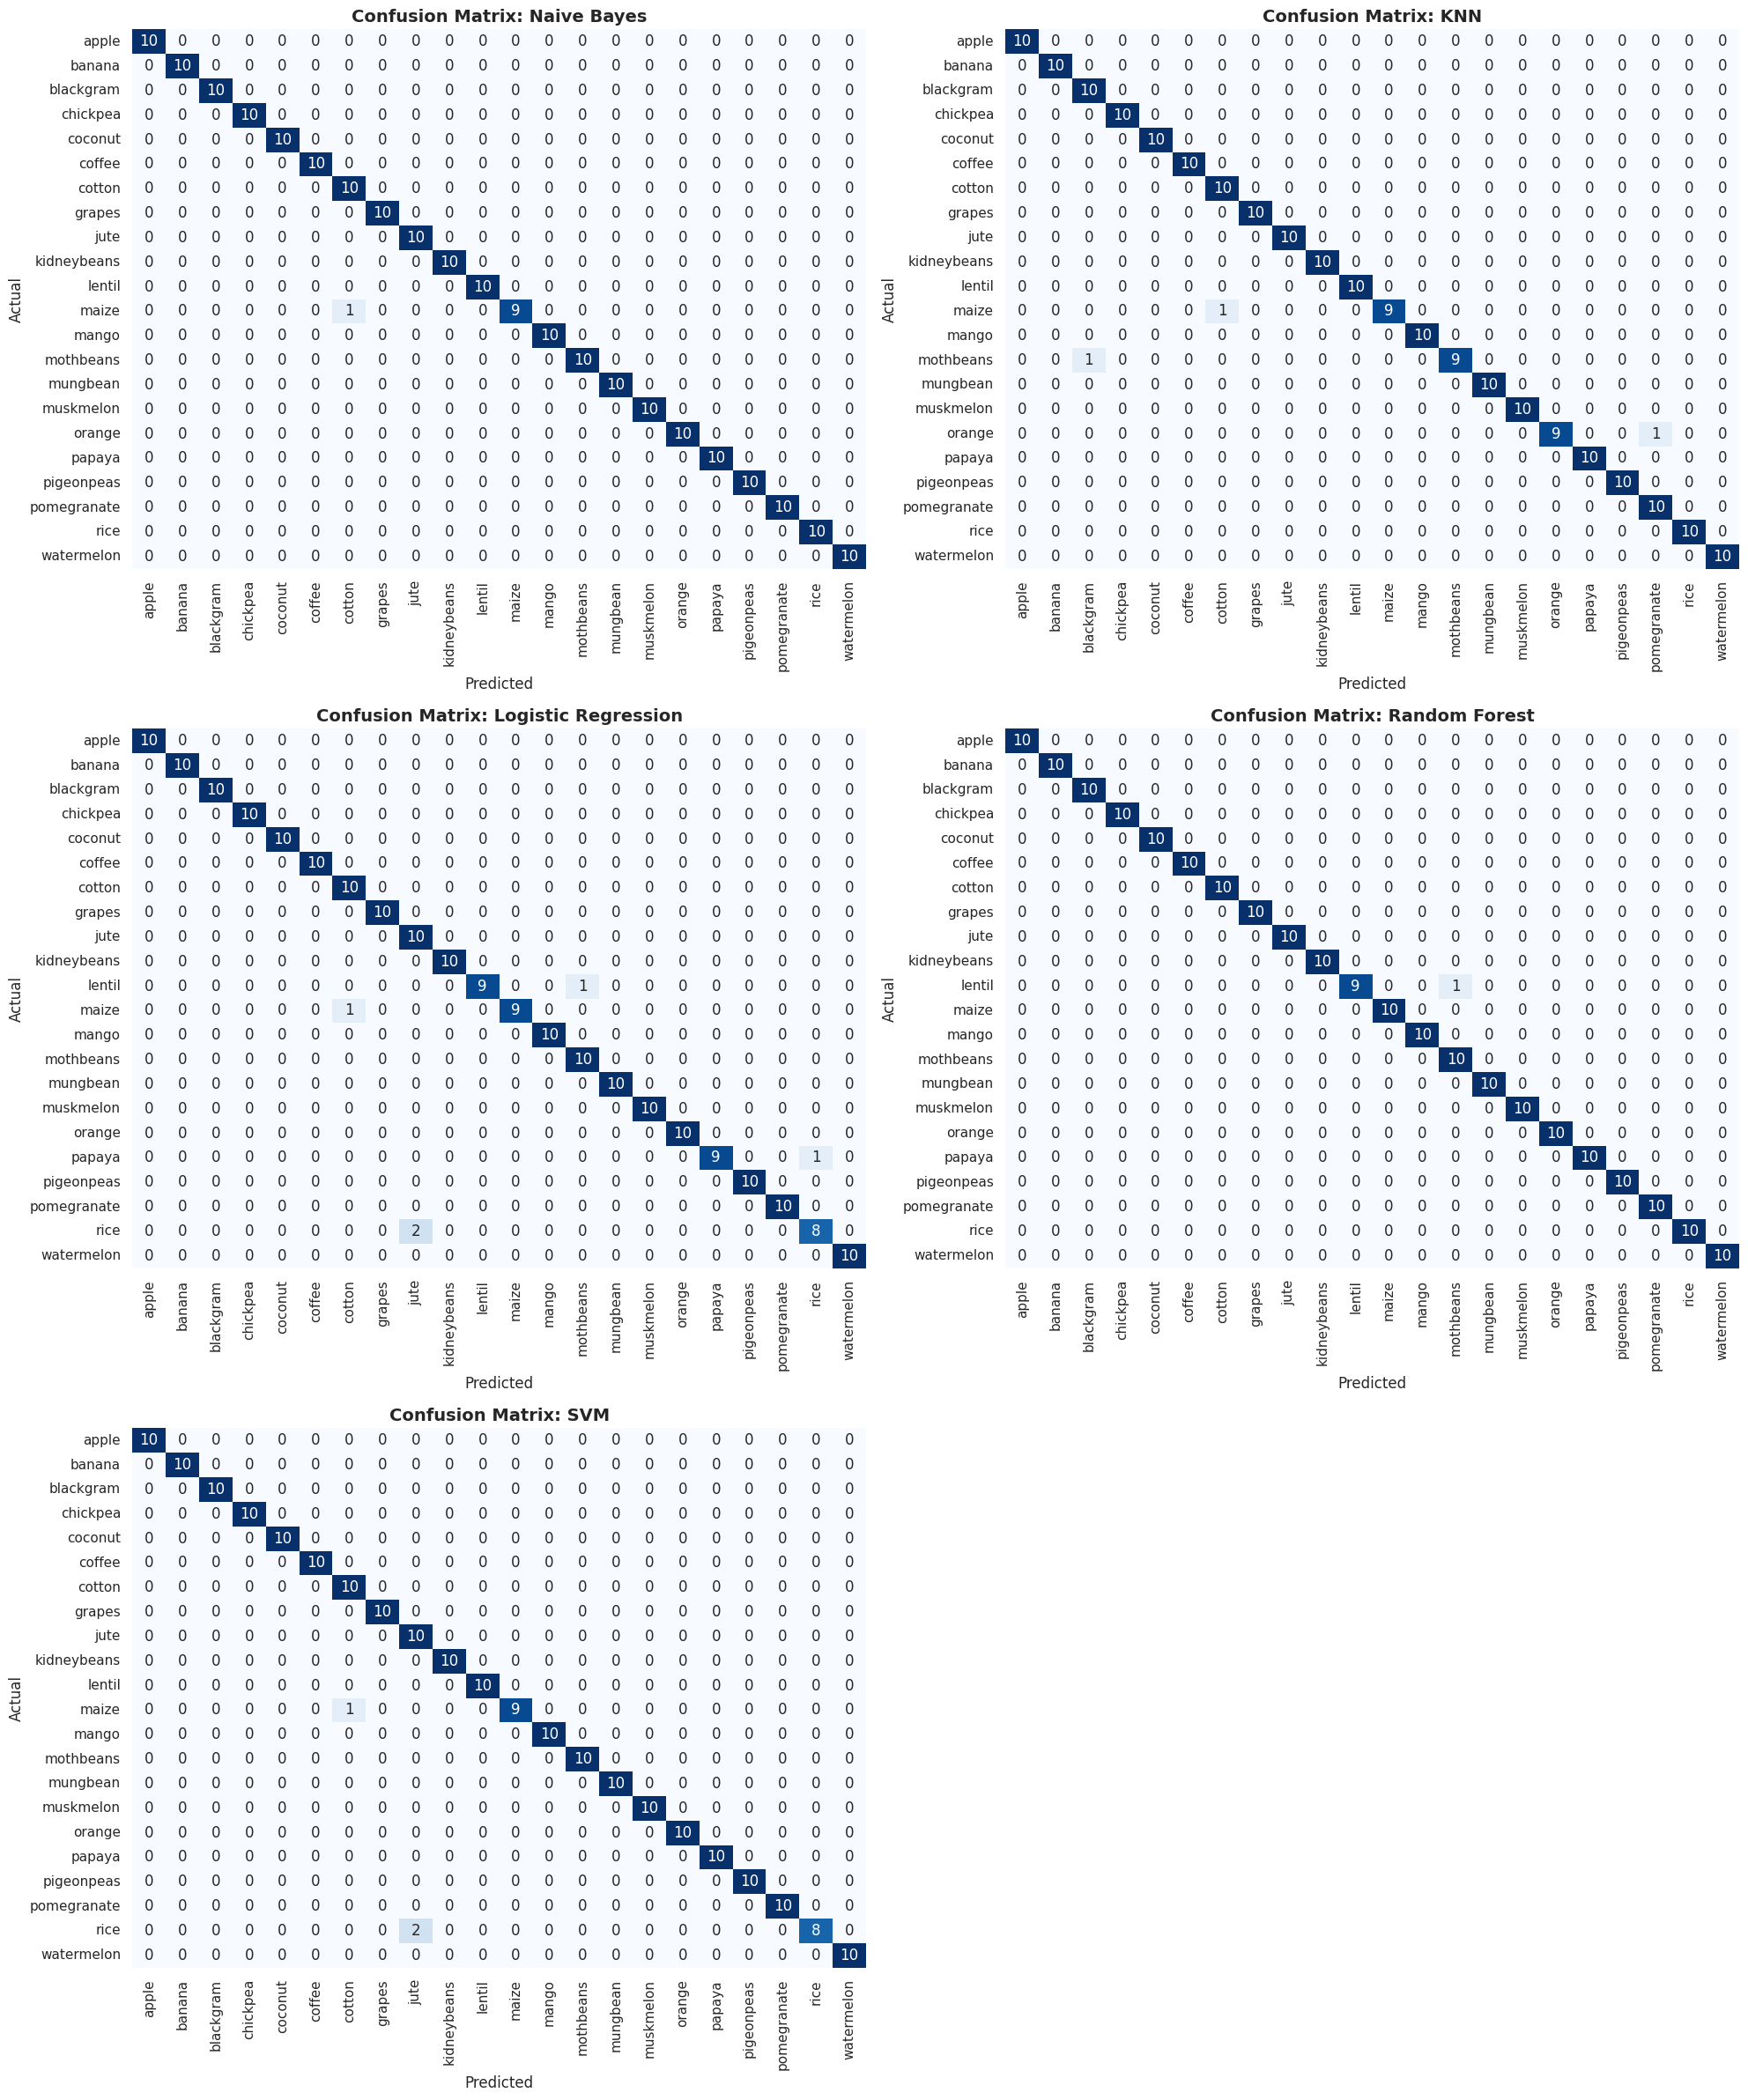

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}", fontweight='bold', fontsize=14)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].tick_params(axis='x', rotation=90)

# Xóa trục dư thừa nếu có
for j in range(len(predictions), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### 2.2 Báo cáo Phân loại (Classification Report) cho Mô hình Tốt nhất

*(Ta in chi tiết cho model đạt F1-Score cao nhất)*

In [5]:
# Tìm model tốt nhất theo F1-Score
best_model_name = max(results, key=lambda x: x['F1-Score'])['Model']
print(f"🌟 Báo cáo chi tiết cho mô hình tốt nhất: {best_model_name}\n")

print(classification_report(y_val, predictions[best_model_name], target_names=class_names))


🌟 Báo cáo chi tiết cho mô hình tốt nhất: Naive Bayes

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        10
      banana       1.00      1.00      1.00        10
   blackgram       1.00      1.00      1.00        10
    chickpea       1.00      1.00      1.00        10
     coconut       1.00      1.00      1.00        10
      coffee       1.00      1.00      1.00        10
      cotton       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        10
        jute       1.00      1.00      1.00        10
 kidneybeans       1.00      1.00      1.00        10
      lentil       1.00      1.00      1.00        10
       maize       1.00      0.90      0.95        10
       mango       1.00      1.00      1.00        10
   mothbeans       1.00      1.00      1.00        10
    mungbean       1.00      1.00      1.00        10
   muskmelon       1.00      1.00      1.00        10
      orange       1.00    

## 3. Tổng Hợp & So Sánh Toàn Diện

In [6]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-Score", ascending=False, inplace=True)
results_df = results_df.reset_index(drop=True)

display(results_df.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
                       .background_gradient(cmap='Oranges', subset=['Train Time (s)']))


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Naive Bayes,0.995455,0.995868,0.995455,0.995443,0.006155
1,Random Forest,0.995455,0.995868,0.995455,0.995443,0.369582
2,KNN,0.986364,0.987603,0.986364,0.986329,0.006784
3,SVM,0.986364,0.988292,0.986364,0.986260,0.160749
4,Logistic Regression,0.977273,0.979109,0.977273,0.977185,0.095789


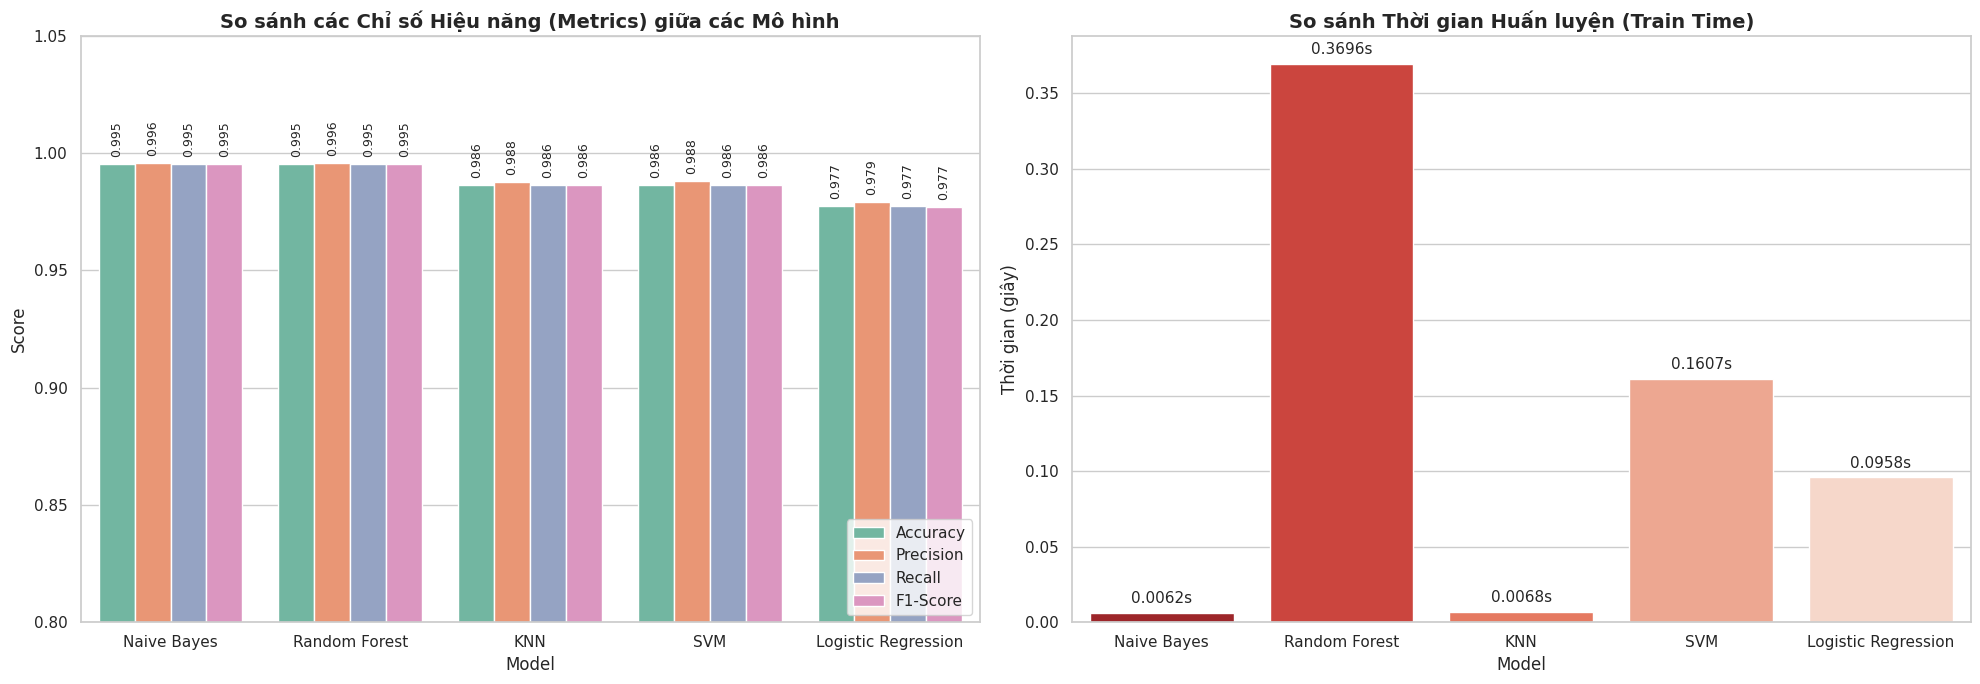

In [7]:
# Chuẩn bị dữ liệu cho biểu đồ so sánh các nhóm metrics
melted_df = results_df.melt(id_vars="Model", 
                            value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                            var_name="Metric", value_name="Score")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Biểu đồ 1: So sánh hiệu năng (Metrics)
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="Set2", ax=axes[0])
axes[0].set_title("So sánh các Chỉ số Hiệu năng (Metrics) giữa các Mô hình", fontweight='bold', fontsize=14)
axes[0].set_ylim(0.8, 1.05)
axes[0].legend(loc='lower right')
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=9, rotation=90, xytext=(0, 5), textcoords='offset points')

# Biểu đồ 2: So sánh thời gian huấn luyện
sns.barplot(data=results_df, x="Model", y="Train Time (s)", palette="Reds_r", ax=axes[1])
axes[1].set_title("So sánh Thời gian Huấn luyện (Train Time)", fontweight='bold', fontsize=14)
axes[1].set_ylabel("Thời gian (giây)")
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}s', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


In [8]:
# Lưu lại kết quả Baseline để các Notebook sau (04, 05, 06) load lên so sánh
import os
os.makedirs('../data/processed', exist_ok=True)
results_df.to_csv('../data/processed/baseline_results.csv', index=False)
print("Đã lưu kết quả baseline vào: data/processed/baseline_results.csv")


Đã lưu kết quả baseline vào: data/processed/baseline_results.csv


## 4. Kết Luận Baseline
- Các mô hình thư viện cho thấy hiệu năng rất tốt do dữ liệu đã được Preprocessing và Feature Engineering tối ưu.
- Các bạn chịu trách nhiệm code From Scratch cần chú ý:
  - **Mục tiêu:** Cố gắng đạt hiệu năng tương đương hoặc tiệm cận với kết quả trên.
  - **Thời gian (Performance):** Code scratch có thể chậm hơn thư viện (do sklearn dùng C/Cython), nhưng độ chính xác (Accuracy/F1) nên bám sát thư viện.
